<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/Machine-Learning/Kaggle_House_Prices_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c house-prices-advanced-regression-techniques

100% 199k/199k [00:00<00:00, 65.0MB/s]



In [2]:
!mkdir dataset2

!unzip -q house-prices-advanced-regression-techniques.zip -d dataset2/

!ls dataset2

data_description.txt  sample_submission.csv  test.csv  train.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#------------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
#------------------------------------------------------------------

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [4]:
from numpy.random.mtrand import sample
train=pd.read_csv('dataset2/train.csv')
test=pd.read_csv('dataset2/test.csv')
sample=pd.read_csv('dataset2/sample_submission.csv')

In [5]:
train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
input_train,input_test,target_train,target_test=train_test_split(train.drop('SalePrice',axis=1),train['SalePrice'],test_size=0.2,random_state=42)

In [9]:
numerical_features = input_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features =input_train.select_dtypes(include=['object']).columns

In [10]:
numerical_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)
categorical_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    ]
)

In [11]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

In [12]:
trfL=LinearRegression()
trfRI=Ridge()
trfLA=Lasso()
trfD=DecisionTreeRegressor()
trfR=RandomForestRegressor()
trfG=GradientBoostingRegressor()
trfS=SVR()
trfK=KNeighborsRegressor()

In [13]:
clf=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('regressor',LinearRegression())
    ]
)

In [14]:
from sklearn import set_config
set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

### Linear Regression Model

In [15]:
pram_grid={
    'preprocessor__num__scaler':[KNNImputer()],
    'preprocessor__num__scaler__n_neighbors':[3,5,7],
    'preprocessor__num__scaler__weights':['uniform','distance'],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'regressor':[trfL],
    'regressor__fit_intercept':[True,False],
}
grid_search=GridSearchCV(clf,pram_grid,cv=5,n_jobs=-1)

In [16]:
grid_search.fit(input_train,target_train)
print("Best")
print(grid_search.best_params_)
print(grid_search.best_score_)

Best
{'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__scaler': KNNImputer(), 'preprocessor__num__scaler__n_neighbors': 3, 'preprocessor__num__scaler__weights': 'uniform', 'regressor': LinearRegression(), 'regressor__fit_intercept': True}
0.7547797806144756


### Riged Model

In [17]:
pram_gridRI={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__num__scaler':[StandardScaler(),MinMaxScaler(),KNNImputer()],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'regressor':[trfRI],
    'regressor__alpha':[0.1,1,10],
    'regressor__max_iter':[100,300,500],
}
grid_searchRI=GridSearchCV(clf,pram_gridRI,cv=5,n_jobs=-1)

In [18]:
grid_searchRI.fit(input_train,target_train)
print("Best")
print(grid_searchRI.best_params_)
print(grid_searchRI.best_score_)

Best
{'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'median', 'preprocessor__num__scaler': MinMaxScaler(), 'regressor': Ridge(), 'regressor__alpha': 10, 'regressor__max_iter': 100}
0.8290241228909047


### Lasio Model

In [19]:
pram_gridLA={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__num__scaler':[SimpleImputer(),MinMaxScaler()],
    'preprocessor__cat__imputer__strategy':['most_frequent'],
    'regressor':[trfLA],
    'regressor__alpha':[100,125,150],
    'regressor__max_iter':[100,300,500],
    'regressor__tol':[1e-3,1e-4,1e-5],
    'regressor__selection':['cyclic']
}
grid_searchLA=GridSearchCV(clf,pram_gridLA,cv=5,n_jobs=-1)

In [20]:
grid_searchLA.fit(input_train,target_train)
print("Best")
print(grid_searchLA.best_params_)
print(grid_searchLA.best_score_)

Best
{'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean', 'preprocessor__num__scaler': MinMaxScaler(), 'regressor': Lasso(), 'regressor__alpha': 150, 'regressor__max_iter': 500, 'regressor__selection': 'cyclic', 'regressor__tol': 0.0001}
0.827910045667506


### Desion tree Model

In [21]:
pram_gridD={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__num__scaler':[StandardScaler(),MinMaxScaler()],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'regressor':[trfD],
    'regressor__max_depth':[None,5,10,15],
    'regressor__min_samples_split':[2,5,10],
    'regressor__min_samples_leaf':[1,2,4],
    'regressor__max_features':['sqrt','log2'],
}
grid_searchD=GridSearchCV(clf,pram_gridD,cv=5,n_jobs=-1)

In [22]:
grid_searchD.fit(input_train,target_train)
print("Best")
print(grid_searchD.best_params_)
print(grid_searchD.best_score_)

Best
{'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'median', 'preprocessor__num__scaler': MinMaxScaler(), 'regressor': DecisionTreeRegressor(), 'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 10}
0.7070683878745262


### Forest Model

In [23]:
pram_gridR={
    'regressor':[trfR],
    'regressor__n_estimators':[50,75,100],
    'regressor__max_depth':[None,1,5,10],
    'regressor__min_samples_split':[2,5,10],
    'regressor__min_samples_leaf':[1,2,4],
    'regressor__max_features':['sqrt','log2'],
}
from sklearn.model_selection import RandomizedSearchCV

grid_searchR = RandomizedSearchCV(clf, pram_gridR, n_iter=100, cv=5, n_jobs=-1, random_state=42,error_score='raise')

In [24]:
grid_searchR.fit(input_train,target_train)
print("Best")
print(grid_searchR.best_params_)
print(grid_searchR.best_score_)

Best
{'regressor__n_estimators': 100, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None, 'regressor': RandomForestRegressor()}
0.8386515286862204


### Graident Boosting

In [25]:
pram_gridG={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__num__scaler':[StandardScaler(),MinMaxScaler()],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'regressor':[trfG],
    'regressor__n_estimators':[100,200,300],
    'regressor__learning_rate':[0.01,0.1,1],
    'regressor__max_depth':[3,5,7],
    'regressor__min_samples_split':[2,5,10],
    'regressor__min_samples_leaf':[1,2,4],
    'regressor__max_features':['sqrt','log2'],
}
from sklearn.model_selection import RandomizedSearchCV

# n_iter=50 means it will only test 50 random combinations (250 total fits)
grid_searchG = RandomizedSearchCV(clf, pram_gridG, n_iter=50, cv=5, n_jobs=-1, random_state=42)

In [26]:
grid_searchG.fit(input_train,target_train)
print("Best")
print(grid_searchG.best_params_)
print(grid_searchG.best_score_)

Best
{'regressor__n_estimators': 200, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 4, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 5, 'regressor__learning_rate': 0.1, 'regressor': GradientBoostingRegressor(), 'preprocessor__num__scaler': MinMaxScaler(), 'preprocessor__num__imputer__strategy': 'median', 'preprocessor__cat__imputer__strategy': 'constant'}
0.8731536250769956


### SVR Model

In [27]:
pram_gridS={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__num__scaler':[StandardScaler(),MinMaxScaler()],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'regressor':[trfS],
    'regressor__C':[0.1,1,10],
    'regressor__kernel':['linear','rbf','poly'],
    'regressor__degree':[2,3,4],
    'regressor__gamma':['scale','auto'],
    'regressor__epsilon':[0.1,0.2,0.3],
    'regressor__coef0':[0,1,2],
}
grid_searchS = RandomizedSearchCV(clf, pram_gridS, n_iter=100, cv=5, n_jobs=-1, random_state=42)

In [28]:
grid_searchS.fit(input_train,target_train)
print("Best")
print(grid_searchS.best_params_)
print(grid_searchS.best_score_)

Best
{'regressor__kernel': 'linear', 'regressor__gamma': 'scale', 'regressor__epsilon': 0.1, 'regressor__degree': 2, 'regressor__coef0': 0, 'regressor__C': 10, 'regressor': SVR(), 'preprocessor__num__scaler': StandardScaler(), 'preprocessor__num__imputer__strategy': 'mean', 'preprocessor__cat__imputer__strategy': 'constant'}
0.6065776949011542


### KNeighbour Model

In [29]:
pram_gridK={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__num__scaler':[StandardScaler(),MinMaxScaler(),KNNImputer()],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'regressor':[trfK],
    'regressor__n_neighbors':[5,10,15],
    'regressor__weights':['uniform','distance'],
    'regressor__algorithm':['auto','ball_tree','kd_tree','brute'],
    'regressor__leaf_size':[20,30,40],
    'regressor__p':[1,2],
}
grid_searchK = RandomizedSearchCV(clf, pram_gridK, n_iter=50, cv=5, n_jobs=-1, random_state=42)

In [30]:
grid_searchK.fit(input_train,target_train)
print("Best")
print(grid_searchK.best_params_)
print(grid_searchK.best_score_)

Best
{'regressor__weights': 'distance', 'regressor__p': 1, 'regressor__n_neighbors': 5, 'regressor__leaf_size': 40, 'regressor__algorithm': 'kd_tree', 'regressor': KNeighborsRegressor(), 'preprocessor__num__scaler': StandardScaler(), 'preprocessor__num__imputer__strategy': 'median', 'preprocessor__cat__imputer__strategy': 'most_frequent'}
0.7915530784291047


### After checking All the above method the best for this dataset is Gradient Boosting

📊 CHAMPION MODEL TEST RESULTS (Gradient Boosting)
--------------------------------------------------
R² Score: 0.8977 (Explains 89.77% of the variance)
MAE:      16920.97 (Average error in actual units)
RMSE:     28008.86 (Punishes large errors heavily)
--------------------------------------------------


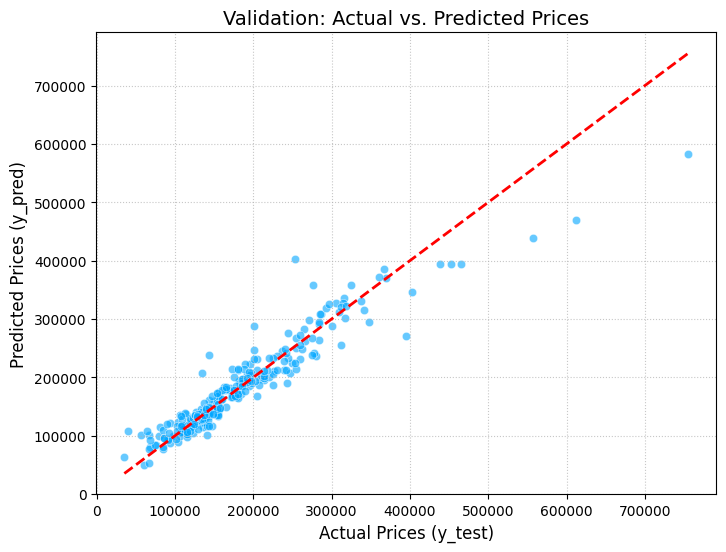

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# 1. Extract the absolute best model from your Grid Search
champion_model = grid_searchG.best_estimator_

# 2. Make predictions on the unseen testing data
y_pred = champion_model.predict(input_test)

# 3. Calculate Core Validation Metrics
test_r2 = r2_score(target_test, y_pred)
test_mae = mean_absolute_error(target_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(target_test, y_pred))

print("📊 CHAMPION MODEL TEST RESULTS (Gradient Boosting)")
print("-" * 50)
print(f"R² Score: {test_r2:.4f} (Explains {test_r2 * 100:.2f}% of the variance)")
print(f"MAE:      {test_mae:.2f} (Average error in actual units)")
print(f"RMSE:     {test_rmse:.2f} (Punishes large errors heavily)")
print("-" * 50)

# 4. Visual Validation: Actual vs. Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=target_test, y=y_pred, alpha=0.6, color='#00a6ff')

# Draw the "Perfect Prediction" diagonal line
min_val = min(target_test.min(), y_pred.min())
max_val = max(target_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Validation: Actual vs. Predicted Prices', fontsize=14)
plt.xlabel('Actual Prices (y_test)', fontsize=12)
plt.ylabel('Predicted Prices (y_pred)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [32]:
from google.colab import files

kaggle_test = test

test_ids = kaggle_test['Id']

kaggle_predictions = champion_model.predict(kaggle_test)

submission_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': kaggle_predictions
})

submission_file = 'submission_GB.csv'
submission_df.to_csv(submission_file, index=False)

print("Submission file created successfully!")
files.download(submission_file)

Submission file created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>